# 17 - Operational Models for Geometries

This notebook is a standalone, executable replacement for Chapter 17's synthesis role in
*Geometric Algebra for Computer Science*. The chapter is short in the source text, but it
asks a large design question: when we build a geometry for computation, what should the
algebra be optimized to do?

The answer is not "use the biggest model" or "store more coordinates just in case." The
answer is operational. Decide which transformations and constructions define the
geometry, then choose a representational space whose metric makes those transformations
native. In a geometric-algebra implementation, native usually means that important
transformations act as orthogonal transformations of the representation space, hence can
be expressed by versor-style sandwich actions or their matrix shadows.

The notebook uses coordinate shadows rather than a full multivector engine. That is
deliberate. Chapter 17 is about model design, so the executable checks below focus on
invariants: covariance of constructions, preservation of metric data, and the difference
between a coordinate container and an operator-ready model.


## Source Span Note

The requested printed-page anchor is pp. 497-502. Before authoring this notebook I checked
the local PDF with `pdftotext`. The extractable Chapter 17 text appears on PDF pages
523-525, corresponding to printed pp. 497-499; PDF page 526 begins Chapter 18 at printed
p. 503. In other words, the intended printed span was checked, but this PDF exposes
Chapter 17's text only through printed p. 499. The explanations here are original study
material based on that synthesis, not copied textbook prose or exercises.


## The Chapter Idea

A geometry can be described by the operations that are supposed to make sense inside it.
If a construction combines objects and then a symmetry is applied, the result should agree
with first applying the symmetry to the inputs and then reconstructing the object. This is
the everyday meaning of covariance. A line through two points should transform into the
line through the transformed points; a distance-preserving motion should preserve the
distances it claims to preserve; a circle primitive should remain a circle under the
operators the model promises to support.

That viewpoint turns model choice into a programming problem. A plain vector space is
excellent for directions, attitudes, linear subspaces, and rotations about a fixed origin.
It is not a full model of finite Euclidean points because translations are not linear in
the same space. Homogeneous coordinates add one coordinate so translations, incidence,
joins, meets, and projective maps become linear. That lift is wonderful for cameras and
projective geometry, but the usual homogeneous inner product is not the Euclidean
distance function. The conformal model adds two null directions so Euclidean distance,
spheres, planes, circles, and rigid motions share one metric-aware representation.

The representational space is therefore not the physical space. It is an engineered space
whose metric and distinguished directions encode the invariants you want operators to
preserve. The point of Chapter 17 is to notice that this is not a one-off trick. It is a
general design workflow: specify the operational symmetries, find a representation in
which they are isometries or otherwise natural linear actions, then implement objects and
algorithms at that level.


## Translation Guide

| Design term | Meaning in this notebook | Practical coding question |
|---|---|---|
| Geometry | A family of objects plus operations that should preserve their intended structure | What must remain true after every supported transform? |
| Operator or symmetry | A transformation that defines sameness for the geometry | Which maps are first-class: rotations, translations, projections, inversions, contact maps? |
| Representational space | The coordinate space in which objects are embedded before using algebraic operations | Are the extra coordinates carrying real invariants or just bookkeeping? |
| Vector-space model | Ordinary Euclidean vector space with a metric on directions and subspaces | Is the problem mainly about directions, angles, and rotations about an origin? |
| Homogeneous model | One added scale coordinate, with finite points and points at infinity handled uniformly | Is incidence, projection, or affine/projective motion the main work? |
| Conformal model | Two added null directions, so Euclidean points become null vectors | Do distances, rounds, and Euclidean motions need to be native operations? |
| Operational model | A model chosen because its algebra makes required operators structure-preserving | Does the representation make the common operations simpler, safer, and testable? |

Read the variables in the code with this table in mind. Arrays are not the geometry by
themselves. They become a geometry only when the supported operations and invariants are
specified.


## Notebook Route

1. Import the local helper module and set up stable artifact paths.
2. Compare the three model families as implementation profiles.
3. Check the vector-space model on rotations of directions.
4. Show why translation forces a homogeneous lift.
5. Use homogeneous joins, meets, and transformed lines to check covariance.
6. Show that homogeneous scale is not the same as Euclidean metric information.
7. Use the conformal model to recover distances from inner products.
8. Apply a conformal rigid motion and verify metric preservation.
9. Run an applied decision workflow for choosing a model from requirements.
10. Finish with sanity checks for numerical invariants and written artifacts.


In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
from IPython.display import Markdown, display

BOOK_ROOT = Path.cwd()
for candidate in (Path.cwd(), *Path.cwd().parents):
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils" / "chapter17_operational_models.py").exists():
        BOOK_ROOT = candidate
        break

if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import save_json, save_matplotlib, save_plotly_html
from utils.chapter17_operational_models import (
    EPS,
    affine_from_homogeneous,
    apply_homogeneous,
    cga_distance_squared,
    cga_infinity_error,
    cga_inner,
    cga_metric_error,
    cga_point2,
    cga_rigid_matrix2,
    cga_transform_points,
    embed_homogeneous,
    hpoint2,
    homogeneous_line,
    line_residual,
    meet_lines,
    model_score_matrix,
    normalize_hpoint,
    pairwise_distances,
    profile_table,
    rotate_vectors,
    rotation2,
    rotation_homogeneous,
    sanity_checks,
    signed_polygon_area,
    transform_line_homogeneous,
    translation_homogeneous,
    vector_space_translation_error,
    weighted_model_scores,
)

np.set_printoptions(precision=4, suppress=True)
ARTIFACT_ROOT = BOOK_ROOT / "artifacts"
CHAPTER_ARTIFACTS = ARTIFACT_ROOT / "chapter-17"
written_artifacts: list[Path] = []


def remember(path: str | Path) -> Path:
    path = Path(path)
    written_artifacts.append(path)
    return path


def rel(path: str | Path) -> str:
    return Path(path).relative_to(BOOK_ROOT).as_posix()


def close_polygon(points: np.ndarray) -> np.ndarray:
    points = np.asarray(points, dtype=float)
    return np.vstack([points, points[0]])


def line_xy(
    line: np.ndarray,
    xlim: tuple[float, float] = (-2.0, 2.0),
    ylim: tuple[float, float] = (-1.8, 1.8),
) -> tuple[np.ndarray, np.ndarray]:
    a, b, c = np.asarray(line, dtype=float)
    if abs(b) > EPS:
        x = np.array(xlim, dtype=float)
        y = (-a * x - c) / b
        return x, y
    y = np.array(ylim, dtype=float)
    x = np.full_like(y, -c / a)
    return x, y


BOOK_ROOT


WindowsPath('Geometric-Algebra-for-Computer-Science')

## Model Comparison as Data

The source chapter lists several geometries to make one point: the representation should
be chosen so the defining symmetries are easy to express and hard to accidentally break.
The table below turns that idea into a small scoring matrix. The numbers are not
universal truth; they are a compact engineering rubric for this notebook. A score of five
means the model makes that requirement feel native. A score of one means the model can
still be useful, but you should expect conversions, special cases, or missing structure.

This is a healthy way to think about geometric algebra in software. A model is not better
merely because it has more coordinates. More coordinates are worthwhile when they make
the desired operators linear, metric-preserving, or uniformly applicable to many object
types. Otherwise they are just extra state to test.


In [2]:
profiles = profile_table()
labels, criteria, score_matrix = model_score_matrix()

summary_lines = ["| Model | Representation | Design question |", "|---|---|---|"]
for row in profiles:
    summary_lines.append(
        f"| {row['name']} | {row['representational_space']} | {row['design_question']} |"
    )
display(Markdown("\n".join(summary_lines)))

fig_scores = go.Figure(
    data=go.Heatmap(
        z=score_matrix,
        x=[criterion.replace("_", " ") for criterion in criteria],
        y=labels,
        colorscale="Viridis",
        zmin=1,
        zmax=5,
        text=score_matrix.astype(int),
        texttemplate="%{text}",
        hovertemplate="%{y}<br>%{x}: %{z}<extra></extra>",
    )
)
fig_scores.update_layout(
    title="Operational fit rubric for common geometry models",
    height=420,
    width=920,
    xaxis_title="Requirement",
    yaxis_title="Model",
)
model_heatmap_path = remember(
    save_plotly_html(fig_scores, "chapter-17", "plots", "model-score-heatmap.html", root=ARTIFACT_ROOT)
)
print(f"saved {rel(model_heatmap_path)}")
fig_scores


| Model | Representation | Design question |
|---|---|---|
| Vector-space model | R^n with the Euclidean metric | Are attitudes, angles, and rotations around a fixed origin enough? |
| Homogeneous model | R^(n+1) up to nonzero scale | Is the core task about incidence, projection, and affine/projective maps? |
| Conformal model | R^(n+1,1) with two null directions | Do distance, rounds, and Euclidean operators need to be first-class? |

saved artifacts/chapter-17/plots/model-score-heatmap.html


## Vector-Space Model: Directions and Orthogonal Operators

In the vector-space model, the representational space is the familiar Euclidean vector
space. The natural objects are directions, weighted directions, and subspaces through the
chosen origin. Rotations are native because they are orthogonal transformations: they
preserve dot products, lengths, angles, oriented areas, and the geometric product
structure that depends on the metric.

The code below rotates a small fan of direction vectors. This is the case where the
ordinary vector model shines. There is no need to embed finite points or invent a point at
infinity. The origin is part of the modeling assumption, and the operators respect it.


In [3]:
angles = np.linspace(0.0, 2.0 * np.pi, 9, endpoint=False)[:-1]
directions = np.column_stack([np.cos(angles), np.sin(angles)])
turn = np.deg2rad(38.0)
rotated_directions = rotate_vectors(directions, turn)

unit_angles = np.linspace(0.0, 2.0 * np.pi, 160)
unit_circle = np.column_stack([np.cos(unit_angles), np.sin(unit_angles)])

fig_vector = go.Figure()
fig_vector.add_trace(
    go.Scatter(x=unit_circle[:, 0], y=unit_circle[:, 1], mode="lines", name="unit circle", line=dict(color="#9aa0a6"))
)
for i, vector in enumerate(directions):
    fig_vector.add_trace(
        go.Scatter(
            x=[0.0, vector[0]],
            y=[0.0, vector[1]],
            mode="lines+markers",
            name="original directions" if i == 0 else None,
            showlegend=i == 0,
            line=dict(color="#1f77b4", width=3),
            marker=dict(size=6),
        )
    )
for i, vector in enumerate(rotated_directions):
    fig_vector.add_trace(
        go.Scatter(
            x=[0.0, vector[0]],
            y=[0.0, vector[1]],
            mode="lines+markers",
            name="rotated directions" if i == 0 else None,
            showlegend=i == 0,
            line=dict(color="#d62728", width=3, dash="dash"),
            marker=dict(size=6),
        )
    )
fig_vector.update_layout(
    title="Vector-space model: rotations preserve directional metric data",
    width=780,
    height=620,
    xaxis=dict(scaleanchor="y", scaleratio=1, range=[-1.25, 1.25], zeroline=True),
    yaxis=dict(range=[-1.25, 1.25], zeroline=True),
)
vector_rotation_path = remember(
    save_plotly_html(fig_vector, "chapter-17", "plots", "vector-space-rotations.html", root=ARTIFACT_ROOT)
)

dot_error = float(np.max(np.abs(directions @ directions.T - rotated_directions @ rotated_directions.T)))
area_error = abs(signed_polygon_area(directions[:4]) - signed_polygon_area(rotated_directions[:4]))
assert dot_error < 1e-12
assert area_error < 1e-12
print(f"dot-product preservation error: {dot_error:.2e}")
print(f"oriented-area preservation error: {area_error:.2e}")
print(f"saved {rel(vector_rotation_path)}")
fig_vector


dot-product preservation error: 2.22e-16
oriented-area preservation error: 0.00e+00
saved artifacts/chapter-17/plots/vector-space-rotations.html


## Why Translation Forces a Lift

The first trap in model design is to confuse a list of coordinates with a representation
that supports the desired operators. A finite Euclidean point can be stored as two
numbers, but ordinary two-dimensional vector space cannot express every translation as a
linear map. A linear map must send the origin to the origin. A translation moves the
origin. Something has to give.

The homogeneous model solves this by adding one coordinate. A point `(x, y)` becomes
`[x, y, 1]`, and a translation becomes a matrix multiplication. The extra coordinate is
not decorative; it turns an affine operation into a linear operation in the
representational space. The plot compares a best-fit ordinary linear map with the exact
homogeneous translation.


In [4]:
points = np.array([[0.0, 0.0], [1.25, 0.05], [0.25, 0.92], [-0.62, 0.42]], dtype=float)
translation = np.array([0.78, -0.36], dtype=float)
fit = vector_space_translation_error(points, translation)

H_translate = translation_homogeneous(*translation)
homogeneous_points = embed_homogeneous(points)
homogeneous_translated = affine_from_homogeneous(apply_homogeneous(H_translate, homogeneous_points))

fig_lift = go.Figure()
for polygon, name, color, dash in [
    (points, "original finite points", "#1f77b4", None),
    (fit["target"], "desired translation", "#2ca02c", None),
    (fit["predicted"], "best ordinary linear fit", "#d62728", "dash"),
    (homogeneous_translated, "homogeneous matrix result", "#9467bd", "dot"),
]:
    closed = close_polygon(polygon)
    fig_lift.add_trace(
        go.Scatter(
            x=closed[:, 0],
            y=closed[:, 1],
            mode="lines+markers",
            name=name,
            line=dict(color=color, width=3, dash=dash),
            marker=dict(size=7),
        )
    )
for source, target in zip(fit["predicted"], fit["target"], strict=True):
    fig_lift.add_trace(
        go.Scatter(
            x=[source[0], target[0]],
            y=[source[1], target[1]],
            mode="lines",
            showlegend=False,
            line=dict(color="#d62728", width=1),
        )
    )
fig_lift.update_layout(
    title="Translation is not linear in bare R^2, but is linear after the homogeneous lift",
    width=860,
    height=620,
    xaxis=dict(scaleanchor="y", scaleratio=1, zeroline=True),
    yaxis=dict(zeroline=True),
)
translation_lift_path = remember(
    save_plotly_html(fig_lift, "chapter-17", "plots", "translation-lift.html", root=ARTIFACT_ROOT)
)

homogeneous_error = float(np.linalg.norm(homogeneous_translated - fit["target"]))
assert fit["error"] > 0.5
assert homogeneous_error < 1e-12
print(f"best bare-vector linear fit error: {fit['error']:.3f}")
print(f"homogeneous translation error: {homogeneous_error:.2e}")
print(f"saved {rel(translation_lift_path)}")
fig_lift


best bare-vector linear fit error: 1.142
homogeneous translation error: 0.00e+00
saved artifacts/chapter-17/plots/translation-lift.html


## Homogeneous Model: Incidence, Join, Meet, and Covariance

The homogeneous model is not just a trick for translation. It makes incidence linear. A
line in the projective plane can be represented by a three-vector `l`, and a point `X`
lies on it when `l dot X = 0`. The line through two points is their homogeneous cross
product; the intersection of two lines is another cross product. These are coordinate
stand-ins for join and meet operations.

The covariance test is the important part. If we build two lines, meet them, and then
apply an affine map, we should get the same finite point as applying the map to the two
lines and meeting the transformed lines. The code below checks exactly that. This is the
operational promise of the homogeneous model: incidence constructions commute with the
supported transformations.


In [5]:
A = hpoint2(-1.08, -0.18)
B = hpoint2(0.98, 0.58)
C = hpoint2(-0.42, 0.92)
D = hpoint2(0.86, -0.72)
line_ab = homogeneous_line(A, B)
line_cd = homogeneous_line(C, D)
meet_ab_cd = normalize_hpoint(meet_lines(line_ab, line_cd))

H_affine = translation_homogeneous(0.46, -0.28) @ rotation_homogeneous(np.deg2rad(24.0))
points_h = np.vstack([A, B, C, D, meet_ab_cd])
points_moved_h = apply_homogeneous(H_affine, points_h)
points_moved = affine_from_homogeneous(points_moved_h)
line_ab_moved = transform_line_homogeneous(H_affine, line_ab)
line_cd_moved = transform_line_homogeneous(H_affine, line_cd)
meet_from_moved_lines = normalize_hpoint(meet_lines(line_ab_moved, line_cd_moved))
meet_from_moved_point = normalize_hpoint(points_moved_h[-1])

fig_incidence = go.Figure()
for line, name, color, dash in [
    (line_ab, "line AB", "#1f77b4", None),
    (line_cd, "line CD", "#ff7f0e", None),
    (line_ab_moved, "transformed line AB", "#1f77b4", "dash"),
    (line_cd_moved, "transformed line CD", "#ff7f0e", "dash"),
]:
    x, y = line_xy(line, xlim=(-2.0, 2.2), ylim=(-1.8, 1.8))
    fig_incidence.add_trace(go.Scatter(x=x, y=y, mode="lines", name=name, line=dict(color=color, width=3, dash=dash)))
original_affine = affine_from_homogeneous(points_h)
fig_incidence.add_trace(
    go.Scatter(x=original_affine[:4, 0], y=original_affine[:4, 1], mode="markers+text", text=["A", "B", "C", "D"], textposition="top center", name="original points", marker=dict(color="#111111", size=9))
)
fig_incidence.add_trace(
    go.Scatter(x=points_moved[:4, 0], y=points_moved[:4, 1], mode="markers+text", text=["A'", "B'", "C'", "D'"], textposition="top center", name="transformed points", marker=dict(color="#9467bd", size=9))
)
fig_incidence.add_trace(
    go.Scatter(x=[meet_ab_cd[0], meet_from_moved_lines[0]], y=[meet_ab_cd[1], meet_from_moved_lines[1]], mode="markers+text", text=["meet", "moved meet"], textposition="bottom center", name="meet points", marker=dict(color="#2ca02c", size=12, symbol="x"))
)
fig_incidence.update_layout(
    title="Homogeneous covariance: transform the meet or meet the transformed lines",
    width=880,
    height=640,
    xaxis=dict(scaleanchor="y", scaleratio=1, zeroline=True),
    yaxis=dict(zeroline=True),
)
homogeneous_incidence_path = remember(
    save_plotly_html(fig_incidence, "chapter-17", "plots", "homogeneous-incidence.html", root=ARTIFACT_ROOT)
)

residual_error = max(abs(line_residual(line_ab_moved, points_moved_h[0])), abs(line_residual(line_ab_moved, points_moved_h[1])))
meet_covariance_error = float(np.linalg.norm(meet_from_moved_lines - meet_from_moved_point))
assert residual_error < 1e-12
assert meet_covariance_error < 1e-12
print(f"transformed incidence residual: {residual_error:.2e}")
print(f"meet covariance error: {meet_covariance_error:.2e}")
print(f"saved {rel(homogeneous_incidence_path)}")
fig_incidence


transformed incidence residual: 1.67e-16
meet covariance error: 1.32e-16
saved artifacts/chapter-17/plots/homogeneous-incidence.html


## Representation Space Is Not Automatically the Metric

Homogeneous coordinates are scale classes. The finite points `[x, y, 1]` and
`[2x, 2y, 2]` represent the same affine location, but their raw coordinate dot products
with another vector are different. That is not a bug. It is a warning label. The
homogeneous model was chosen because incidence and projective maps are native, not
because the ordinary dot product in `R^3` has become Euclidean distance.

Operational model design always asks this question: which quantities are meaningful in
the representation, and which are just coordinate artifacts? A good notebook should check
that distinction numerically, because many geometry bugs are born from accidentally
measuring the wrong space.


In [6]:
P = hpoint2(1.2, -0.35, 1.0)
P_same = 3.0 * P
Q = hpoint2(-0.15, 0.82, 1.0)

affine_same_error = float(np.linalg.norm(affine_from_homogeneous(P) - affine_from_homogeneous(P_same)))
raw_dot = float(P @ Q)
raw_dot_scaled = float(P_same @ Q)
euclidean_distance = float(np.linalg.norm(affine_from_homogeneous(P) - affine_from_homogeneous(Q)))

assert affine_same_error < 1e-12
assert abs(raw_dot_scaled - raw_dot) > 1.0
print(f"same affine point after rescaling error: {affine_same_error:.2e}")
print(f"raw homogeneous dot(P, Q): {raw_dot:.3f}")
print(f"raw homogeneous dot(3P, Q): {raw_dot_scaled:.3f}")
print(f"actual Euclidean distance between represented points: {euclidean_distance:.3f}")


same affine point after rescaling error: 5.55e-17
raw homogeneous dot(P, Q): 0.533
raw homogeneous dot(3P, Q): 1.599
actual Euclidean distance between represented points: 1.786


## Conformal Model: Distance as an Inner-Product Effect

The conformal model uses a larger representational space for a different reason. It
embeds Euclidean points as null vectors. In this notebook's 2-D helper, a point `(x, y)`
is represented as `[x, y, 1, 0.5*(x*x + y*y)]` with a metric where the last two basis
directions are null and paired. The self-inner product of an embedded point is zero,
while the inner product of two embedded points recovers their squared Euclidean distance.

The surface below shows the `ni` coordinate of the lift, colored by squared distance from
an anchor point as recovered through the conformal inner product. The visual is a
coordinate shadow, not the whole conformal algebra, but it captures the design idea:
distance has moved from an external helper function into the metric structure of the
representation.


In [7]:
xs = np.linspace(-2.0, 2.0, 37)
ys = np.linspace(-1.8, 1.8, 35)
xx, yy = np.meshgrid(xs, ys)
ni_coordinate = 0.5 * (xx**2 + yy**2)
anchor = np.array([0.42, -0.28])
flat_points = np.column_stack([xx.ravel(), yy.ravel()])
distance_color = np.array([cga_distance_squared(point, anchor) for point in flat_points]).reshape(xx.shape)

sample_points = np.array([[-1.3, -0.9], [-0.7, 0.8], [0.4, -0.28], [1.2, 0.65], [1.6, -1.0]])
sample_lift = np.column_stack([sample_points, 0.5 * np.sum(sample_points**2, axis=1)])
anchor_lift = np.r_[anchor, 0.5 * float(anchor @ anchor)]

fig_cga_lift = go.Figure()
fig_cga_lift.add_trace(
    go.Surface(
        x=xx,
        y=yy,
        z=ni_coordinate,
        surfacecolor=distance_color,
        colorscale="Plasma",
        colorbar=dict(title="squared distance"),
        opacity=0.82,
        name="conformal point lift",
    )
)
fig_cga_lift.add_trace(
    go.Scatter3d(
        x=sample_lift[:, 0],
        y=sample_lift[:, 1],
        z=sample_lift[:, 2],
        mode="markers+text",
        text=["P1", "P2", "anchor", "P4", "P5"],
        textposition="top center",
        name="sample embedded points",
        marker=dict(size=5, color="#111111"),
    )
)
fig_cga_lift.add_trace(
    go.Scatter3d(
        x=[anchor_lift[0]],
        y=[anchor_lift[1]],
        z=[anchor_lift[2]],
        mode="markers",
        name="distance anchor",
        marker=dict(size=8, color="#00cc96", symbol="diamond"),
    )
)
fig_cga_lift.update_layout(
    title="Conformal lift: null embedded points, colored by metric distance to an anchor",
    width=900,
    height=680,
    scene=dict(xaxis_title="e1", yaxis_title="e2", zaxis_title="ni coefficient"),
)
conformal_lift_path = remember(
    save_plotly_html(fig_cga_lift, "chapter-17", "plots", "conformal-distance-lift.html", root=ARTIFACT_ROOT)
)

null_errors = [abs(cga_inner(cga_point2(point), cga_point2(point))) for point in sample_points]
distance_errors = [abs(cga_distance_squared(point, anchor) - float(np.sum((point - anchor) ** 2))) for point in sample_points]
assert max(null_errors) < 1e-12
assert max(distance_errors) < 1e-12
print(f"max null residual for sample points: {max(null_errors):.2e}")
print(f"max distance recovery error: {max(distance_errors):.2e}")
print(f"saved {rel(conformal_lift_path)}")
fig_cga_lift


max null residual for sample points: 0.00e+00
max distance recovery error: 4.44e-16
saved artifacts/chapter-17/plots/conformal-distance-lift.html


## Conformal Rigid Motions as Metric-Preserving Operators

The previous cell checked points. The next cell checks operators. A Euclidean rigid
motion can be represented by a linear operator on conformal point vectors. The matrix
used here is a coordinate shadow of the versor action: it preserves the conformal metric,
keeps the infinity direction fixed, and sends embedded points to embedded points for the
transformed Euclidean locations.

This is the operational-model payoff. In a bare coordinate implementation, every object
type often needs its own transformation rule. In a conformal model, points, point pairs,
lines, circles, spheres, and planes can be made to share the same operator pattern. Even
in this simplified matrix version, we can test the promise by checking metric preservation
and pairwise-distance preservation.


In [8]:
shape = np.array([[-0.9, -0.45], [0.55, -0.62], [0.95, 0.35], [-0.12, 0.82]], dtype=float)
R = rotation2(np.deg2rad(34.0))
t = np.array([0.72, 0.38], dtype=float)
M_cga = cga_rigid_matrix2(R, t)
shape_moved = cga_transform_points(shape, M_cga)
expected_shape_moved = shape @ R.T + t

fig_motion = go.Figure()
for polygon, name, color in [
    (shape, "original polygon", "#1f77b4"),
    (shape_moved, "conformal operator result", "#d62728"),
    (expected_shape_moved, "ordinary Euclidean formula", "#2ca02c"),
]:
    closed = close_polygon(polygon)
    fig_motion.add_trace(
        go.Scatter(x=closed[:, 0], y=closed[:, 1], mode="lines+markers", name=name, line=dict(color=color, width=3), marker=dict(size=8))
    )
fig_motion.update_layout(
    title="Conformal rigid operator agrees with Euclidean motion and preserves distances",
    width=820,
    height=620,
    xaxis=dict(scaleanchor="y", scaleratio=1, zeroline=True),
    yaxis=dict(zeroline=True),
)
conformal_motion_path = remember(
    save_plotly_html(fig_motion, "chapter-17", "plots", "conformal-rigid-motion.html", root=ARTIFACT_ROOT)
)

motion_error = float(np.linalg.norm(shape_moved - expected_shape_moved))
distance_preservation_error = float(np.max(np.abs(pairwise_distances(shape) - pairwise_distances(shape_moved))))
metric_error = cga_metric_error(M_cga)
infinity_error = cga_infinity_error(M_cga)
assert motion_error < 1e-12
assert distance_preservation_error < 1e-12
assert metric_error < 1e-12
assert infinity_error < 1e-12
print(f"point motion error: {motion_error:.2e}")
print(f"pairwise-distance preservation error: {distance_preservation_error:.2e}")
print(f"conformal metric preservation error: {metric_error:.2e}")
print(f"infinity-vector preservation error: {infinity_error:.2e}")
print(f"saved {rel(conformal_motion_path)}")
fig_motion


point motion error: 0.00e+00
pairwise-distance preservation error: 4.44e-16
conformal metric preservation error: 3.16e-16
infinity-vector preservation error: 0.00e+00
saved artifacts/chapter-17/plots/conformal-rigid-motion.html


## Applied Lab: A Decision Workflow

An operational model should be chosen by requirements, not habit. The workflow below is
intentionally simple enough to reuse in a project notebook.

1. List the object families that must be represented without constant conversion.
2. List the transformations that define sameness for the task.
3. Decide which invariants must be measured directly: incidence, angle, distance,
   tangency, contact, projective cross-ratio, or something else.
4. Score candidate models by native support and implementation cost.
5. Prototype the top model with invariants that fail loudly when the representation is
   being misused.

The lab ranks the three models for a few workloads. A camera-calibration workload rewards
projective maps and incidence, so homogeneous coordinates should win. A robot or graphics
workload involving rigid motions, distances, and spheres should favor conformal
coordinates. A normal-field or attitude workload should not pay for unnecessary point
machinery.


normal-field attitudes         -> Vector-space model (4.64)
camera incidence               -> Homogeneous model (4.83)
robot geometry with spheres    -> Conformal model (5.00)
mixed exploratory prototype    -> Conformal model (4.31)


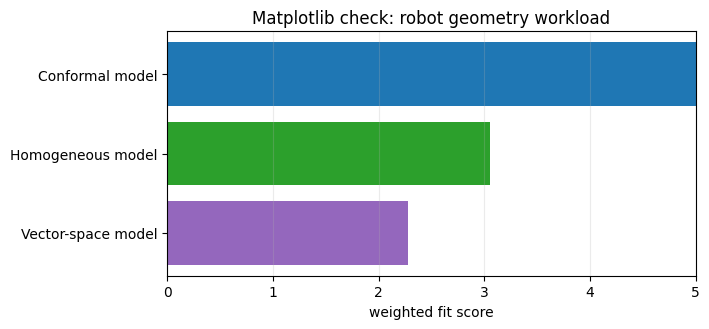

saved artifacts/chapter-17/data/model-rankings.json
saved artifacts/chapter-17/plots/decision-workflow-rankings.html
saved artifacts/chapter-17/plots/robot-workload-scores.png


In [9]:
workloads = {
    "normal-field attitudes": {"directions": 5, "rigid_motions": 2, "simplicity": 4},
    "camera incidence": {"incidence": 5, "projective_maps": 5, "simplicity": 2},
    "robot geometry with spheres": {"metric_distances": 5, "rigid_motions": 5, "rounds": 5, "incidence": 3},
    "mixed exploratory prototype": {"directions": 2, "incidence": 3, "metric_distances": 3, "rigid_motions": 3, "rounds": 2, "simplicity": 3},
}
rankings = {name: weighted_model_scores(weights) for name, weights in workloads.items()}
ranking_json_path = remember(
    save_json({"workloads": workloads, "rankings": rankings}, "chapter-17", "data", "model-rankings.json", root=ARTIFACT_ROOT)
)

for workload, ranking in rankings.items():
    leader = ranking[0]
    print(f"{workload:30s} -> {leader['model']} ({leader['score']:.2f})")

fig_rank = go.Figure()
for model in labels:
    fig_rank.add_trace(
        go.Bar(
            x=list(workloads.keys()),
            y=[next(row["score"] for row in rankings[workload] if row["model"] == model) for workload in workloads],
            name=model,
        )
    )
fig_rank.update_layout(
    title="Decision workflow: rank models by workload requirements",
    width=980,
    height=560,
    yaxis_title="weighted fit score (1-5)",
    barmode="group",
    xaxis_tickangle=-18,
)
ranking_plot_path = remember(
    save_plotly_html(fig_rank, "chapter-17", "plots", "decision-workflow-rankings.html", root=ARTIFACT_ROOT)
)

robot_rows = rankings["robot geometry with spheres"]
fig_mpl, ax = plt.subplots(figsize=(7.2, 3.4))
ax.barh([row["model"] for row in robot_rows][::-1], [row["score"] for row in robot_rows][::-1], color=["#9467bd", "#2ca02c", "#1f77b4"])
ax.set_xlim(0, 5)
ax.set_xlabel("weighted fit score")
ax.set_title("Matplotlib check: robot geometry workload")
ax.grid(axis="x", alpha=0.25)
fig_mpl.tight_layout()
robot_score_path = remember(
    save_matplotlib(fig_mpl, "chapter-17", "plots", "robot-workload-scores.png", root=ARTIFACT_ROOT)
)
plt.show()

assert rankings["camera incidence"][0]["model"] == "Homogeneous model"
assert rankings["robot geometry with spheres"][0]["model"] == "Conformal model"
assert rankings["normal-field attitudes"][0]["model"] == "Vector-space model"
print(f"saved {rel(ranking_json_path)}")
print(f"saved {rel(ranking_plot_path)}")
print(f"saved {rel(robot_score_path)}")
fig_rank


## What to Do When No Existing Model Fits

Chapter 17 also points beyond the three models we have used. Some geometries are not yet
comfortably operational in the same way. Projective geometry is a good example:
homogeneous coordinates represent projective transformations linearly, but the chapter's
higher bar would ask for a model where the defining projective symmetries are
versor-like operators for a suitable metric. Contact geometry is another tempting case
for computer science, because collision, tangency, and path constraints are operational
ideas rather than just sets of points.

The design workflow still applies when the model is not known in advance. Start from the
transformations and invariants. Ask what must be preserved. Ask whether your candidate
representation turns those transformations into isometries, linear maps, or at least
stable algebraic operations. Then write small invariant tests before writing a large
application. If the tests require constant exceptions, the representation is probably
fighting the geometry.

This is the practical reading of operational. The model is judged by what it lets you do
reliably.


## Final Sanity Checks

The final cell checks the notebook's claims without relying on the plots. It verifies that
bare vector space does not exactly model translation as a linear map, that homogeneous
translation and incidence are exact to floating-point precision, that conformal point
embeddings are null, that distances are recovered from the conformal inner product, that
conformal rigid motion preserves the metric and infinity direction, and that every
artifact path produced by the notebook exists on disk.


In [10]:
checks = sanity_checks()
assert checks["vector_space_translation_fit_error"] > 0.5
assert checks["homogeneous_translation_error"] < 1e-12
assert checks["homogeneous_incidence_error"] < 1e-12
assert checks["cga_null_error"] < 1e-12
assert checks["cga_distance_error"] < 1e-12
assert checks["cga_metric_error"] < 1e-12
assert checks["cga_infinity_error"] < 1e-12
assert checks["cga_motion_error"] < 1e-12

for artifact in written_artifacts:
    assert artifact.exists(), artifact

print("chapter sanity checks passed")
for name, value in checks.items():
    print(f"{name}: {value:.2e}")
print("artifacts:")
for artifact in written_artifacts:
    print(f"- {rel(artifact)}")


chapter sanity checks passed
vector_space_translation_fit_error: 1.22e+00
homogeneous_translation_error: 0.00e+00
homogeneous_incidence_error: 0.00e+00
cga_null_error: 0.00e+00
cga_distance_error: 0.00e+00
cga_metric_error: 1.60e-16
cga_infinity_error: 0.00e+00
cga_motion_error: 0.00e+00
artifacts:
- artifacts/chapter-17/plots/model-score-heatmap.html
- artifacts/chapter-17/plots/vector-space-rotations.html
- artifacts/chapter-17/plots/translation-lift.html
- artifacts/chapter-17/plots/homogeneous-incidence.html
- artifacts/chapter-17/plots/conformal-distance-lift.html
- artifacts/chapter-17/plots/conformal-rigid-motion.html
- artifacts/chapter-17/data/model-rankings.json
- artifacts/chapter-17/plots/decision-workflow-rankings.html
- artifacts/chapter-17/plots/robot-workload-scores.png


## Chapter Takeaways

An operational model is a representation chosen around the operations that define the
geometry. The vector-space model is lean and powerful when directions and orthogonal
transformations are the problem. The homogeneous model earns its extra coordinate when
affine and projective incidence must be linear. The conformal model earns two null
directions when distance, rounds, and Euclidean motions should be part of the algebraic
fabric rather than external helper code.

The main implementation habit is to separate representational space from physical space.
Coordinates answer "where is the data stored?" The operational model answers "which
constructions and transformations are guaranteed to stay meaningful?" Once that
distinction is clear, model choice becomes testable. Every major section of this notebook
wrote a visual artifact and an invariant check because the right model should make the
right invariants almost boring.

For a new geometry project, begin with the operators. If the operators preserve the
constructions you care about, the objects have permanence inside the model. If they do
not, no amount of pretty coordinate notation will save the implementation from special
cases. That is the quiet but important design lesson of Chapter 17.
